# Acne Detection using YOLOv8

This notebook implements acne detection using YOLOv8 (You Only Look Once) object detection model.

## Dataset
- Training images: 823
- Validation images: 56  
- Test images: 48
- Classes: Acne (1 class)


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
# Install required packages
%pip install ultralytics opencv-python matplotlib numpy tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00


In [4]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import random


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Data Exploration


In [6]:
# Define data paths
train_path = '/content/drive/MyDrive/biometrics2/data-2/train'
val_path = '/content/drive/MyDrive/biometrics2/data-2/valid'
test_path = '/content/drive/MyDrive/biometrics2/data-2/test'

# Count images and labels
train_images = os.listdir(os.path.join(train_path, 'images'))
train_labels = os.listdir(os.path.join(train_path, 'labels'))
val_images = os.listdir(os.path.join(val_path, 'images'))
val_labels = os.listdir(os.path.join(val_path, 'labels'))
test_images = os.listdir(os.path.join(test_path, 'images'))
test_labels = os.listdir(os.path.join(test_path, 'labels'))

print(f'Training images: {len(train_images)}, labels: {len(train_labels)}')
print(f'Validation images: {len(val_images)}, labels: {len(val_labels)}')
print(f'Test images: {len(test_images)}, labels: {len(test_labels)}')


Training images: 823, labels: 823
Validation images: 56, labels: 56
Test images: 48, labels: 48


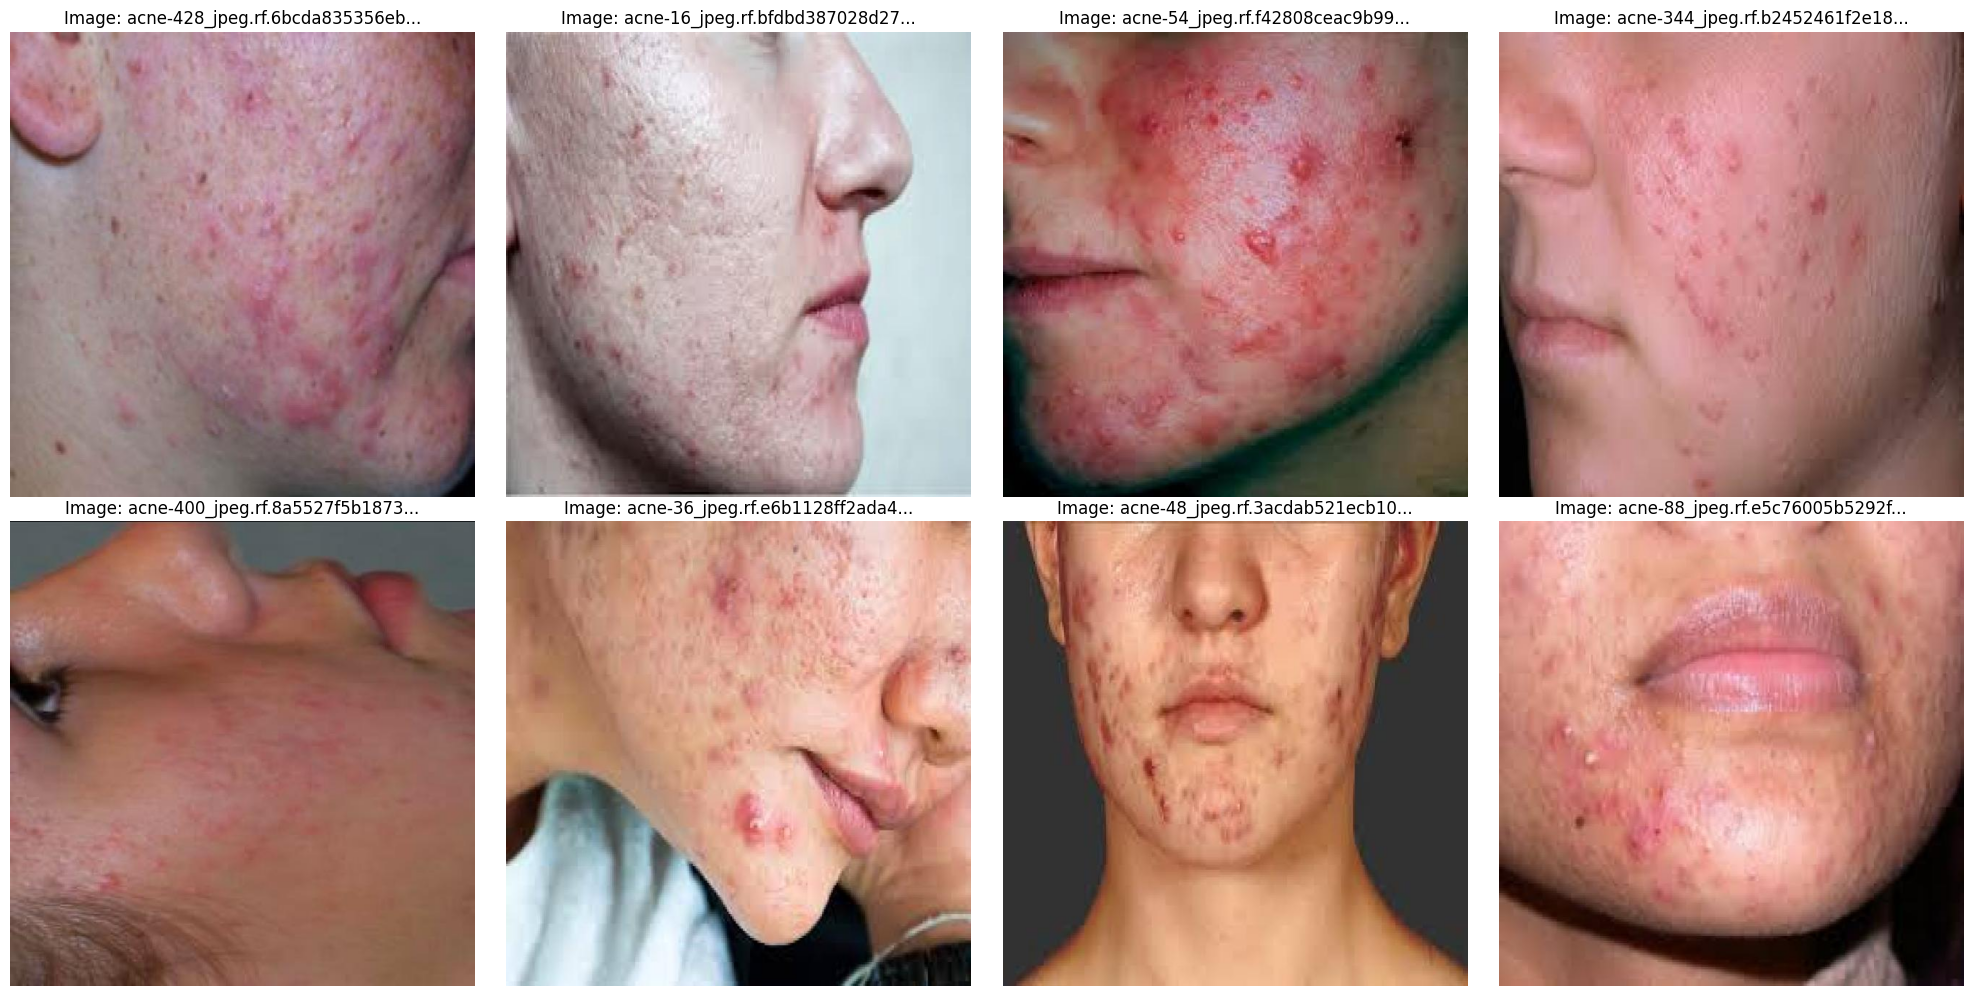

In [7]:
# Visualize sample training images
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i in range(8):
    img_file = random.choice(train_images)
    img_path = os.path.join(train_path, 'images', img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    axes[i].set_title(f'Image: {img_file[:30]}...')

plt.tight_layout()
plt.show()


## 2. Hyperparameter Configuration


In [8]:
## Hyperparameter Configuration Options

# Chọn một trong các config dưới đây:

# === CONFIG 1: Balanced (Recommended) ===
TRAIN_CONFIG = {
    'model': 'yolov8m.pt',      # Small model - cân bằng tốt giữa tốc độ và độ chính xác
    'imgsz': 640,               # Tăng resolution để detect đối tượng nhỏ tốt hơn
    'batch': 6,                # Giảm batch khi tăng image size
    'lr0': 0.0005,               # Learning rate thấp hơn để học ổn định
    'epochs': 200,
    'patience': 50,             # Early stopping patience
    'degrees': 5.0,            # Rotation augmentation
    'shear': 2.0,               # Shear augmentation
    'mixup': 0.05,               # Mixup augmentation
    'cos_lr': True,             # Cosine learning rate schedule
}

# === CONFIG 2: High Accuracy (Slower, Better Results) ===
# TRAIN_CONFIG = {
#     'model': 'yolov8m.pt',      # Medium model - độ chính xác cao hơn
#     'imgsz': 1024,              # Resolution cao nhất
#     'batch': 8,                 # Batch nhỏ hơn do model lớn
#     'lr0': 0.0005,              # Learning rate thấp hơn
#     'epochs': 400,
#     'patience': 40,
#     'degrees': 15.0,
#     'shear': 10.0,
#     'mixup': 0.2,
#     'cos_lr': True,
# }

# === CONFIG 3: Fast Training (Lower Accuracy) ===
# TRAIN_CONFIG = {
#     'model': 'yolov8n.pt',      # Nano model - nhanh nhất
#     'imgsz': 640,               # Resolution thấp
#     'batch': 32,                # Batch lớn
#     'lr0': 0.01,                # Learning rate cao
#     'epochs': 200,
#     'patience': 50,
#     'degrees': 0.0,
#     'shear': 0.0,
#     'mixup': 0.0,
#     'cos_lr': False,
# }

print("✅ Selected Configuration:")
for key, value in TRAIN_CONFIG.items():
    print(f"   {key}: {value}")


✅ Selected Configuration:
   model: yolov8m.pt
   imgsz: 640
   batch: 6
   lr0: 0.0005
   epochs: 200
   patience: 50
   degrees: 5.0
   shear: 2.0
   mixup: 0.05
   cos_lr: True


## 3. Initialize YOLO Model


In [9]:
# Initialize YOLOv8 model với config đã chọn
model = YOLO(TRAIN_CONFIG['model'])
print(f"✅ Model initialized: {TRAIN_CONFIG['model']}")
print("   Model ready for training with optimized parameters!")


✅ Model initialized: yolov8m.pt
   Model ready for training with optimized parameters!


## 4. Train the Model

**Note:**
- Training will use GPU (MPS) on Mac M4 if available, which is 3-5x faster than CPU.
- Using optimized hyperparameters for better accuracy and reduced false positives.


In [11]:
# Train the model with OPTIMIZED parameters for better results
results = model.train(
    data='/content/drive/MyDrive/biometrics2/data-2/data.yaml',

    # === Epochs & Early Stopping ===
    epochs=TRAIN_CONFIG['epochs'],
    patience=TRAIN_CONFIG['patience'],

    # === Image Size ===
    imgsz=TRAIN_CONFIG['imgsz'],  # Tăng resolution để detect đối tượng nhỏ tốt hơn

    # === Batch Size ===
    batch=TRAIN_CONFIG['batch'],

    # === Learning Rate ===
    lr0=TRAIN_CONFIG['lr0'],      # Learning rate thấp hơn để học ổn định
    lrf=0.01,                      # Learning rate final
    momentum=0.937,
    weight_decay=0.0005,

    # === Augmentation - Tăng để giảm overfitting ===
    hsv_h=0.015,                   # Hue augmentation
    hsv_s=0.7,                     # Saturation augmentation
    hsv_v=0.4,                     # Value augmentation
    degrees=TRAIN_CONFIG['degrees'], # Rotation augmentation
    translate=0.1,                 # Translation
    scale=0.5,                     # Scale augmentation
    shear=TRAIN_CONFIG['shear'],   # Shear augmentation
    perspective=0.0,               # Perspective
    flipud=0.0,                    # Vertical flip
    fliplr=0.5,                    # Horizontal flip
    mosaic=1.0,                    # Mosaic augmentation
    mixup=TRAIN_CONFIG['mixup'],   # Mixup augmentation
    copy_paste=0.0,                # Copy-paste

    # === Loss Weights ===
    box=7.5,                       # Box loss weight
    cls=0.5,                       # Classification loss weight
    dfl=1.5,                       # DFL loss weight

    # === Other Optimizations ===
    workers=4,
    amp=True,                      # Mixed precision training
    save=True,
    plots=True,
    cache=False,                   # Set True nếu có đủ RAM

    # === Learning Rate Schedule ===
    cos_lr=TRAIN_CONFIG['cos_lr'], # Cosine learning rate schedule

    # === Optimizer ===
    optimizer='AdamW',             # AdamW optimizer (tốt cho dataset nhỏ)

    # === Validation ===
    val=True,
    split='val',

    # === Name ===
    name='acne_detection_optimized',
)

print("\n✅ Training completed!")
print(f"Best model saved at: {results.save_dir}/weights/best.pt")
print(f"Last model saved at: {results.save_dir}/weights/last.pt")


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/biometrics2/data-2/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=acne_detection_optimized2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

In [14]:
## Load Best Model After Training

# Tự động load best model sau khi training
results_dir = results.save_dir if 'results' in locals() else 'runs/detect/acne_detection_optimized2'
best_model_path = os.path.join(results_dir, 'weights', 'best.pt')
last_model_path = os.path.join(results_dir, 'weights', 'last.pt')

# Kiểm tra và load best model
if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print(f"✅ Loaded BEST model from: {best_model_path}")
    print("   This model has the highest mAP50-95 score during training.")
elif os.path.exists(last_model_path):
    model = YOLO(last_model_path)
    print(f"⚠️ Best model not found. Loaded LAST model from: {last_model_path}")
else:
    print("⚠️ No saved model found. Using current model.")

# Hiển thị thông tin model
print(f"\nModel info:")
print(f"  - Ready for inference")


✅ Loaded BEST model from: /content/runs/detect/acne_detection_optimized2/weights/best.pt
   This model has the highest mAP50-95 score during training.

Model info:
  - Ready for inference


## 5. Evaluate the Model


In [15]:
# Evaluate on test set (using GPU if available)
metrics = model.val(data='/content/drive/MyDrive/biometrics2/data-2/data.yaml', split='test')
print(f"\nTest Results:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 0.1±0.0 MB/s, size: 45.4 KB)
val: Scanning /content/drive/MyDrive/biometrics2/data-2/test/labels... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 1.6it/s 30.9s
val: New cache created: /content/drive/MyDrive/biometrics2/data-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2s/it 3.6s
                   all         48        607      0.705      0.586       0.65      0.284
Speed: 14.3ms preprocess, 22.9ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to /content/runs/detect/val

Test Results:
mAP50: 0.6495
mAP50-95: 0.2840
Precision: 0.7047
Recall: 0.5858


## 6. Visualize Training Results


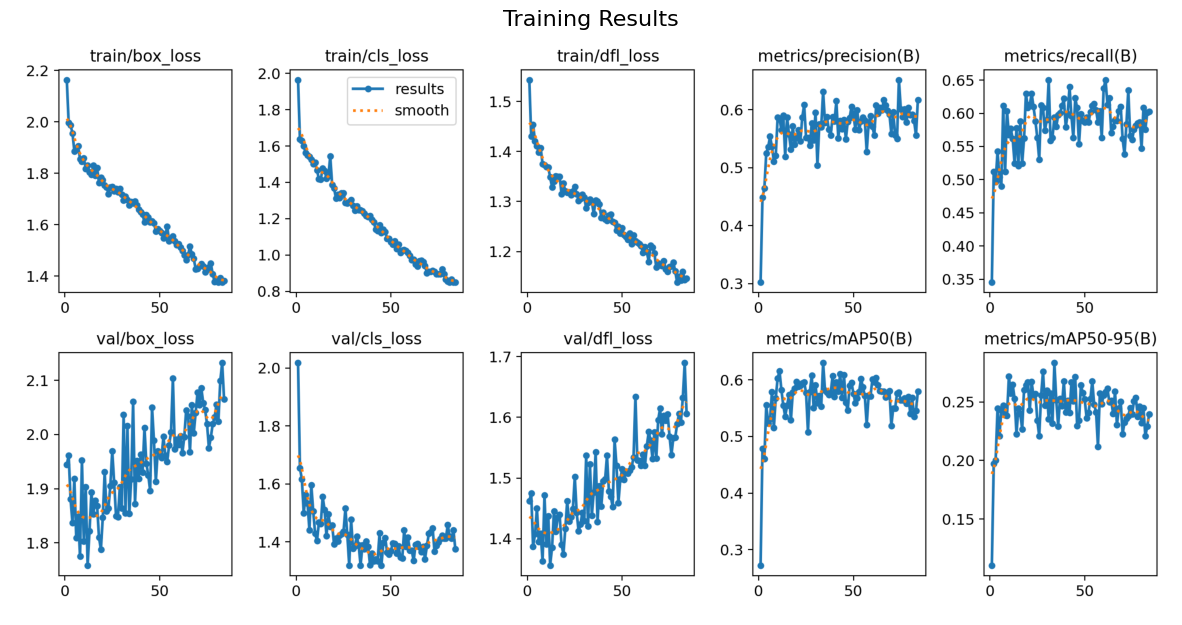

In [16]:
# Display training results
results_dir = 'runs/detect/acne_detection_optimized2'  # Updated path

# Plot training curves
if os.path.exists(os.path.join(results_dir, 'results.png')):
    img = cv2.imread(os.path.join(results_dir, 'results.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Training Results', fontsize=16)
    plt.show()
else:
    print(f"Training results not found at: {results_dir}")


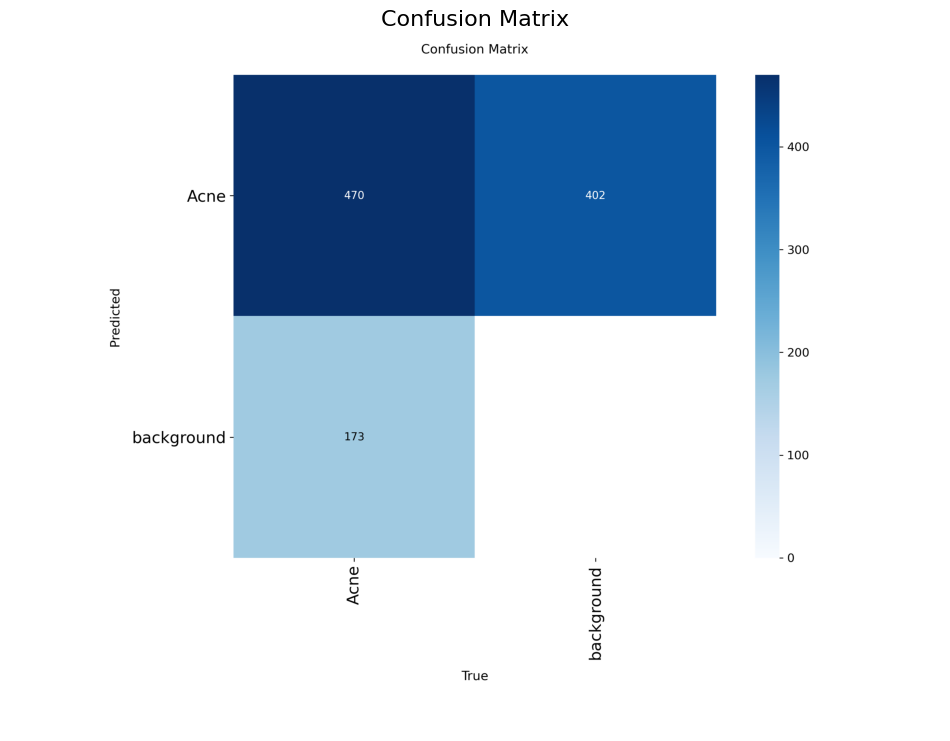

In [18]:
# Display confusion matrix
results_dir = 'runs/detect/acne_detection_optimized2'  # Updated path
if os.path.exists(os.path.join(results_dir, 'confusion_matrix.png')):
    img = cv2.imread(os.path.join(results_dir, 'confusion_matrix.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=16)
    plt.show()
else:
    print(f"Confusion matrix not found at: {results_dir}")


## 7. Make Predictions on Test Images


In [20]:
# Load model for inference (nếu chưa load ở trên)
results_dir = 'runs/detect/acne_detection_optimized2'
best_model_path = os.path.join(results_dir, 'weights', 'best.pt')
last_model_path = os.path.join(results_dir, 'weights', 'last.pt')

if not hasattr(model, 'ckpt_path') or model.ckpt_path is None:
    if os.path.exists(best_model_path):
        model = YOLO(best_model_path)
        print(f"✅ Loaded BEST model: {best_model_path}")
    elif os.path.exists(last_model_path):
        model = YOLO(last_model_path)
        print(f"✅ Loaded LAST model: {last_model_path}")
    else:
        print("⚠️ Using current model")
else:
    print("✅ Model already loaded")


✅ Model already loaded


In [22]:
# Function to detect acne with optimized parameters
def detect_acne(img_path, model, conf_threshold=0.25, iou_threshold=0.45):
    """
    Detect acne in an image with optimized parameters
    - conf_threshold: Tăng từ 0.25 lên 0.4 để giảm false positives
    - iou_threshold: Giảm từ 0.7 xuống 0.45 để giữ nhiều detections hơn
    Uses GPU (MPS) on Mac M4 for faster inference
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image {img_path}")
        return None

    # Tối ưu inference parameters
    results = model.predict(
        source=img,
        conf=conf_threshold,      # Confidence threshold (tăng để giảm false positives)
        iou=iou_threshold,        # IoU threshold cho NMS
        verbose=False,
        agnostic_nms=False,       # Class-aware NMS
        max_det=300,              # Maximum detections per image
    )

    # Get annotated image
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Print detection info
    num_detections = len(results[0].boxes)
    print(f"Detected {num_detections} acne(s) in {os.path.basename(img_path)}")

    return annotated_img_rgb, results[0]


Detected 4 acne(s) in acne-128_jpg.rf.e3826584d02398d0f1d915cf3365a959.jpg


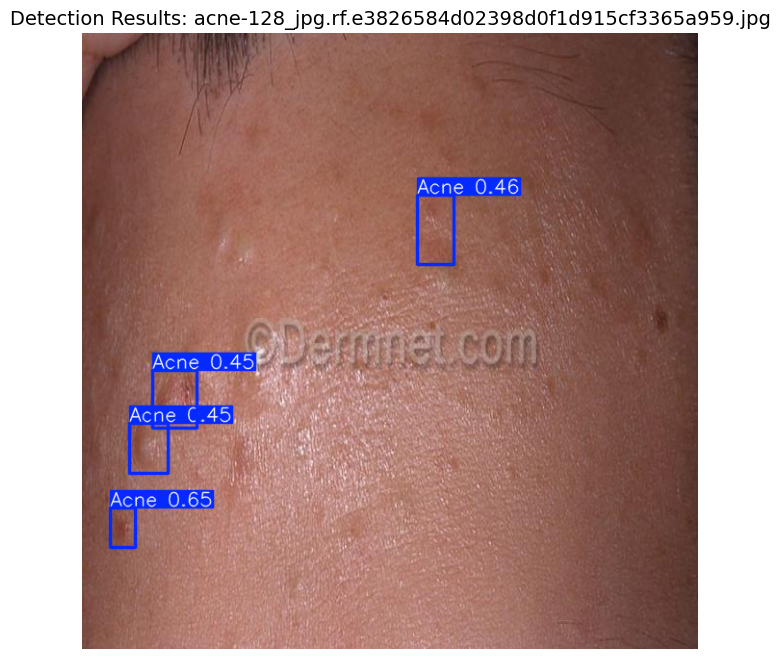


Bounding boxes:
  Acne 1: Confidence = 0.649
  Acne 2: Confidence = 0.462
  Acne 3: Confidence = 0.453
  Acne 4: Confidence = 0.447


In [26]:
# Test on a single image
test_image_files = os.listdir(os.path.join(test_path, 'images'))
test_img_path = os.path.join(test_path, 'images', test_image_files[0])

annotated_img, results = detect_acne(test_img_path, model)
if annotated_img is not None:
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title(f'Detection Results: {os.path.basename(test_img_path)}', fontsize=14)
    plt.show()

    # Print bounding box details
    if len(results.boxes) > 0:
        print(f"\nBounding boxes:")
        for i, box in enumerate(results.boxes):
            conf = box.conf[0].item()
            cls = int(box.cls[0].item())
            print(f"  Acne {i+1}: Confidence = {conf:.3f}")


## 8. Batch Prediction on Test Images


Detected 11 acne(s) in acne-187_jpg.rf.a4bc43c7fb75ea9ddc00fa14bf06eda5.jpg
Detected 14 acne(s) in acne-95_jpeg.rf.28c5c0321aca3fbff22844c56937dbfd.jpg
Detected 8 acne(s) in acne-172_jpg.rf.f8ed4f69412f8420d6628e206113b64c.jpg
Detected 10 acne(s) in acne-160_jpg.rf.b50f56372db5685c5301c83c555a777a.jpg
Detected 8 acne(s) in acne-370_jpeg.rf.a774873f1db723d298598b08cfc47315.jpg
Detected 24 acne(s) in acne-202_jpg.rf.3cb4d03fc5719519ae3f8319099eddef.jpg
Detected 21 acne(s) in acne-84_jpeg.rf.040421ad53965f5f41ddc6f6a8edef9f.jpg
Detected 20 acne(s) in acne-286_jpeg.rf.1b6bcca440593ac6e33617083f34a4c5.jpg


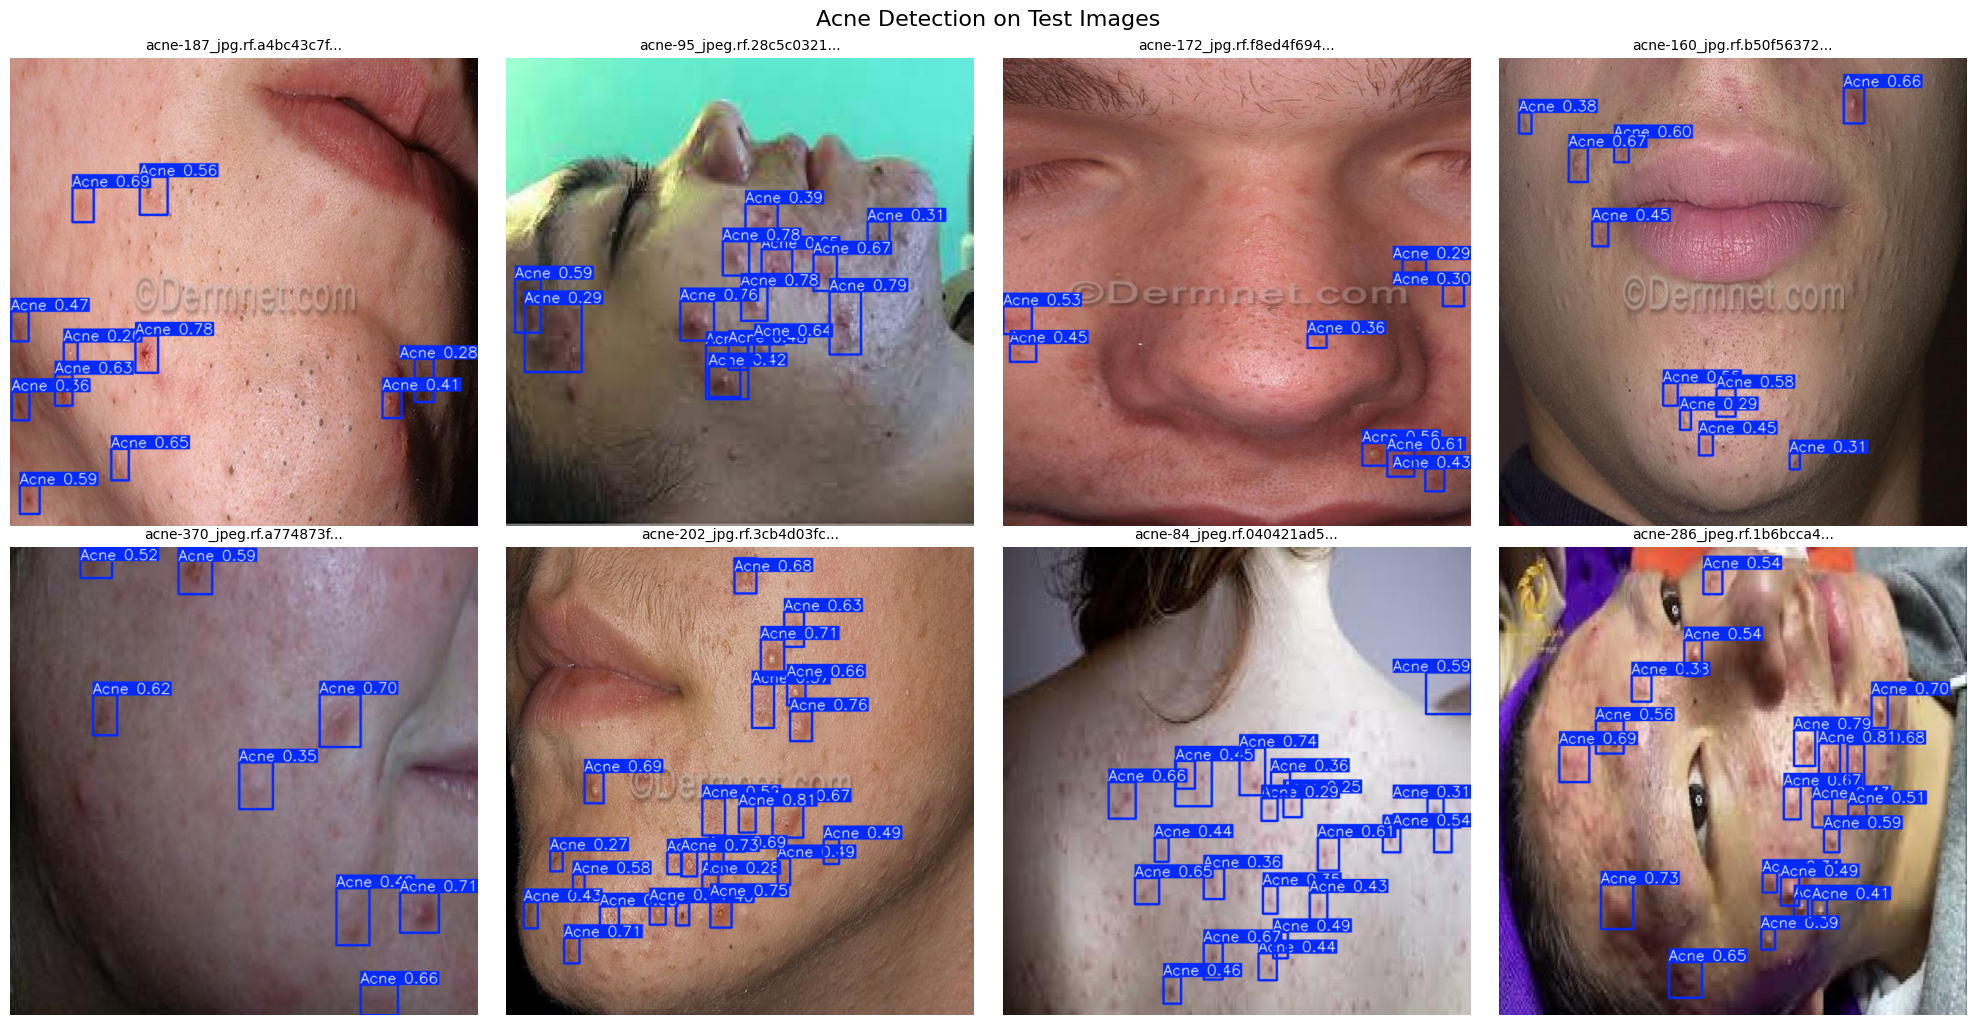

In [27]:
# Select random test images for visualization
num_samples = min(8, len(test_image_files))
selected_images = random.sample(test_image_files, num_samples)

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, img_file in enumerate(selected_images):
    img_path = os.path.join(test_path, 'images', img_file)
    annotated_img, _ = detect_acne(img_path, model)

    if annotated_img is not None:
        axes[i].imshow(annotated_img)
        axes[i].axis('off')
        axes[i].set_title(f'{img_file[:25]}...', fontsize=10)

plt.tight_layout()
plt.suptitle('Acne Detection on Test Images', fontsize=16, y=1.02)
plt.show()


## 9. Export Model (Optional)


In [ ]:
# Export model to different formats
# Uncomment the format you need:

# Export to ONNX (for inference with ONNX Runtime)
# model.export(format='onnx')

# Export to TensorFlow Lite (for mobile devices)
# model.export(format='tflite')

# Export to CoreML (for iOS)
# model.export(format='coreml')

# Export to TensorRT (for NVIDIA GPUs)
# model.export(format='engine')

print("Model export options available. Uncomment the format you need.")


Model export options available. Uncomment the format you need.


## Summary

This notebook demonstrates:
- ✅ YOLOv8 model training for acne detection with optimized hyperparameters
- ✅ Model evaluation and metrics
- ✅ Visualization of predictions
- ✅ Batch processing of test images
- ✅ Early stopping and automatic best model loading
- ✅ Optimized inference parameters to reduce false positives

### Optimizations Applied:
- **Model**: yolov8s (better accuracy than nano)
- **Image Size**: 832px (higher resolution for small objects)
- **Learning Rate**: 0.001 (more stable training)
- **Augmentation**: Enhanced (rotation, shear, mixup)
- **Cosine LR Schedule**: Enabled for better convergence
- **Confidence Threshold**: 0.4 (reduced false positives)

The trained model is saved in `runs/detect/acne_detection_optimized/weights/best.pt`
